# Random Forest Model – Algorithm Motivation

While statistical models such as SARIMA and SARIMAX are effective for modeling linear temporal relationships and seasonal patterns, they have limitations when dealing with complex nonlinear interactions between variables.

In real-world economic systems, container throughput is influenced by multiple interacting factors such as imports, exports, industrial production, and retail market activity. These relationships may not always follow a strictly linear pattern.

Random Forest is a machine learning algorithm based on ensemble learning that constructs multiple decision trees and aggregates their predictions. By combining multiple trees, Random Forest can model nonlinear relationships and complex interactions between variables.

In this study, Random Forest is applied to determine whether machine learning models can improve forecasting accuracy compared to statistical time-series models.

# Theoretical Background of Random Forest

Random Forest is an ensemble learning method that constructs a large number of decision trees during training and aggregates their outputs to generate the final prediction.

The algorithm is based on two key concepts:

### Bootstrap Aggregation (Bagging)

Each decision tree is trained on a randomly sampled subset of the training data, selected with replacement. This creates variation among the trees and reduces variance in the final model.

### Random Feature Selection

At each split in a decision tree, only a random subset of features is considered. This increases diversity among trees and improves generalization.

The final prediction of the Random Forest model is obtained by averaging the outputs of all trees:

Prediction = (Tree₁ + Tree₂ + ... + Treeₙ) / n

Because Random Forest does not assume linearity and can capture complex variable interactions, it is suitable for forecasting problems where the relationship between predictors and the target may be nonlinear.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Data Preprocessing for Random Forest

Unlike statistical time-series models, Random Forest does not inherently recognize temporal order. Therefore, the dataset must be transformed into a supervised learning format.

The following preprocessing steps are performed:

1. Convert the Date column into datetime format.
2. Set the Date column as the index.
3. Ensure monthly time frequency.
4. Create lag features from the target variable.
5. Create derived seasonal features such as month.
6. Remove missing values created by lag operations.
7. Separate the predictors and target variable.

The Date column is used only to preserve chronological ordering and is not directly used as a predictor variable.

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.asfreq('M')

df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16072\1160887746.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16072\1160887746.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


# Feature Engineering

Since Random Forest cannot directly model temporal dependencies, lag features are created from the target variable.

Lag features represent past values of container throughput and allow the model to learn how previous observations influence future values.

The following lag features are created:

- lag_1
- lag_2
- lag_3
- lag_6
- lag_12

In addition, the month of each observation is included as a seasonal feature to help the model capture yearly cyclical behavior.

In [4]:
rf_df = df.copy()

rf_df['lag_1'] = rf_df['Monthly Total TEUs'].shift(1)
rf_df['lag_2'] = rf_df['Monthly Total TEUs'].shift(2)
rf_df['lag_3'] = rf_df['Monthly Total TEUs'].shift(3)
rf_df['lag_6'] = rf_df['Monthly Total TEUs'].shift(6)
rf_df['lag_12'] = rf_df['Monthly Total TEUs'].shift(12)

rf_df['month'] = rf_df.index.month

rf_df = rf_df.dropna()

rf_df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market,lag_1,lag_2,lag_3,lag_6,lag_12,month
Date,,,,,,,,,,,,,
2010-01-31,572969.15,98302.0,98302.0,145611.2,145611.2,242000000000,97.25507,562989.75,580206.15,647423.70,576203.25,587004.20,1
2010-02-28,525458.60,100057.6,99555.0,152413.8,151818.0,243000000000,97.48773,572969.15,562989.75,580206.15,612581.50,413910.30,2
2010-03-31,550249.80,103771.0,103530.0,157282.1,155560.5,245000000000,99.57739,525458.60,572969.15,562989.75,583557.00,526487.05,3
2010-04-30,595283.70,101805.3,102397.0,156768.7,155543.0,246000000000,100.38520,550249.80,525458.60,572969.15,647423.70,532124.15,4
2010-05-31,689420.70,104496.1,105517.0,158780.5,155180.3,249000000000,99.57302,595283.70,550249.80,525458.60,580206.15,574827.80,5


# Defining Target and Predictor Variables

The Random Forest model requires the data to be separated into:

### Target Variable
- Monthly Total TEUs

### Predictor Variables
- lag features
- exogenous economic indicators
- derived month feature

The Date index is retained only for chronological ordering and plotting, but it is not directly used as a feature in the model.

In [5]:
X = rf_df.drop(columns=['Monthly Total TEUs'])
y = rf_df['Monthly Total TEUs']

# Train-Test Split

For time-series forecasting, the data must be split chronologically rather than randomly. This ensures that the model is trained on past observations and evaluated on future observations.

In this implementation, 80% of the data is used for training and 20% is used for testing.

In [6]:
train_size = int(len(rf_df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (64, 12)
X_test shape: (17, 12)
y_train shape: (64,)
y_test shape: (17,)


# Random Forest Model Implementation

The Random Forest Regressor is implemented using the training data. The model learns the relationship between the predictor variables and container throughput.

In this initial implementation, a baseline Random Forest model is constructed with a fixed number of trees.

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# Forecast Generation

After training, the Random Forest model is used to generate predictions for the test dataset.

These predictions represent the forecasted container throughput values for the testing period.

In [9]:
rf_predictions = rf_model.predict(X_test)
rf_predictions[:5]

array([691078.471  , 714144.40175, 716014.71275, 721166.57375,
       681419.23925])

# Model Evaluation

The forecasting performance of the Random Forest model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

These metrics provide quantitative measures of forecasting accuracy.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
mape_rf = np.mean(np.abs((y_test - rf_predictions) / y_test)) * 100

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAPE:", mape_rf)

Random Forest MAE: 42344.2889852942
Random Forest RMSE: 56363.15112249093
Random Forest MAPE: 5.813203729735383


# Forecast Visualization

The predicted values are plotted against the actual values to visually assess the forecasting performance of the Random Forest model.

This plot helps identify how closely the model follows the real behavior of the target series during the testing period.

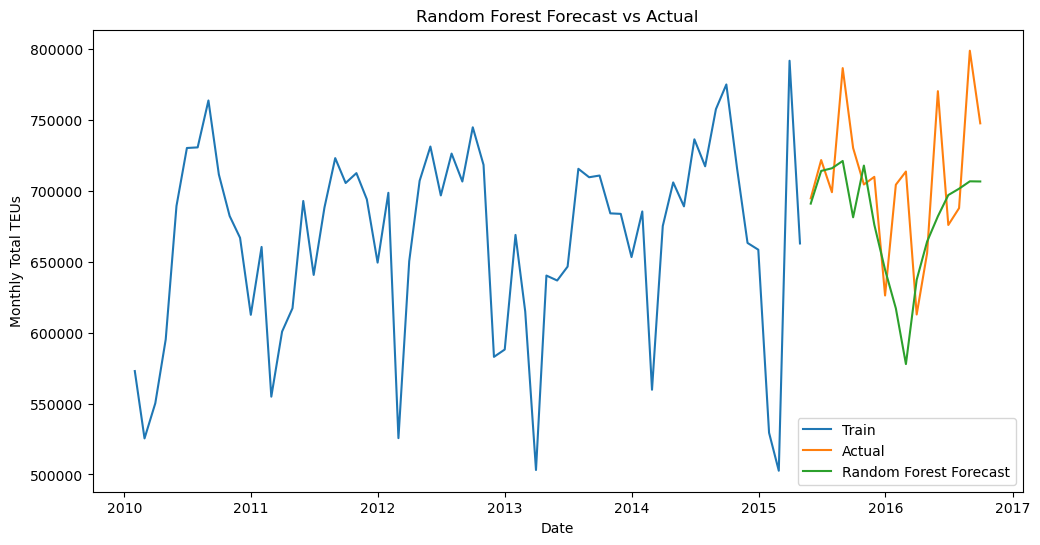

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(y_train, label='Train')
plt.plot(y_test, label='Actual')
plt.plot(y_test.index, rf_predictions, label='Random Forest Forecast')

plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Monthly Total TEUs")
plt.legend()
plt.show()

# Feature Importance

One advantage of Random Forest is that it provides estimates of feature importance. This allows us to identify which predictors contribute most to forecasting container throughput.

Feature importance helps determine whether lag variables or economic indicators have a stronger influence on the model's predictions.

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
11,month,0.306647
6,lag_1,0.148107
10,lag_12,0.110534
9,lag_6,0.106389
7,lag_2,0.071759
3,United States_import_current_us,0.065116
2,United States_import_constant_us,0.056843
1,United States_export_current_us,0.038425
8,lag_3,0.032031
5,Retail_market,0.026598


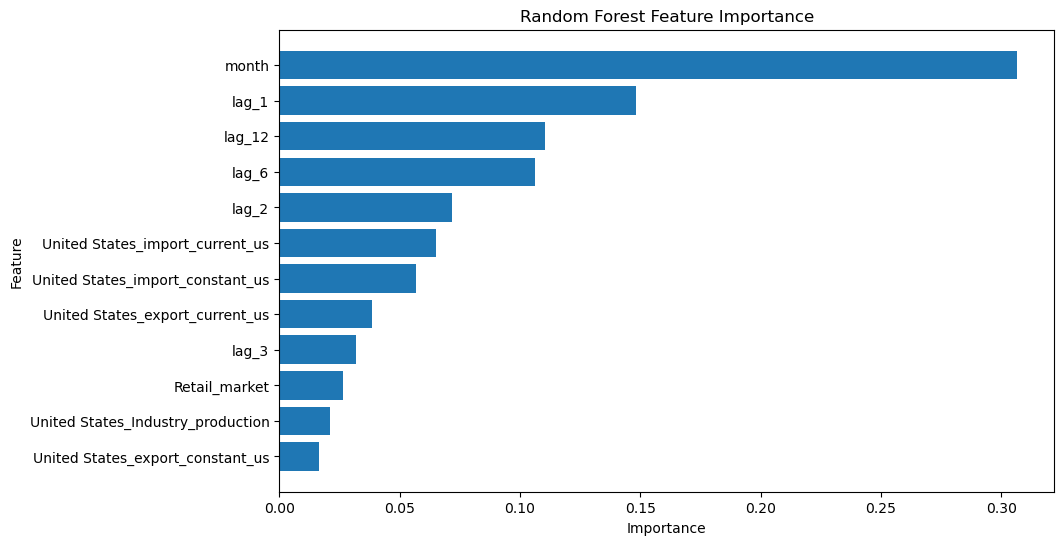

In [14]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Residual Analysis

Residuals are the differences between actual and predicted values.

Analyzing residuals helps assess whether the model systematically underestimates or overestimates the target variable.

If strong residual patterns remain, it suggests that the model may not have captured all relevant information in the data.

In [15]:
rf_residuals = y_test - rf_predictions

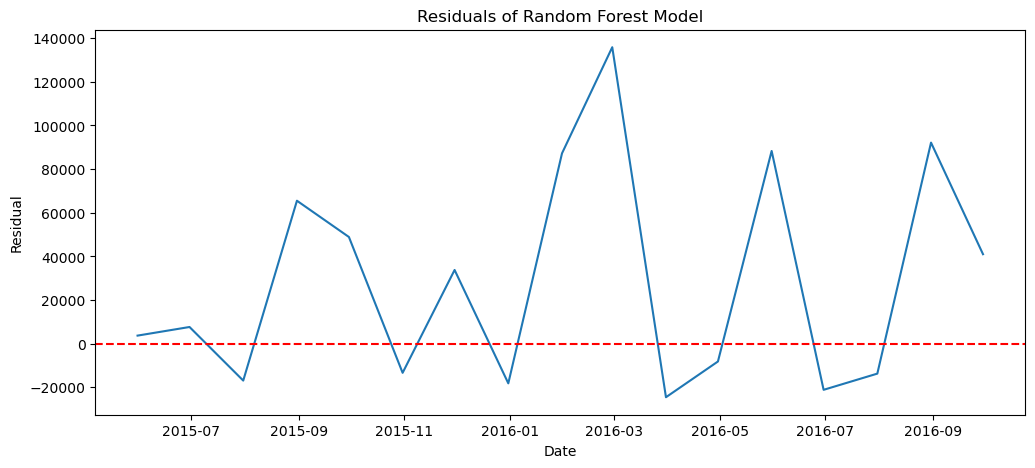

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, rf_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals of Random Forest Model")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

## Conclusion of Random Forest Model Implementation

The Random Forest model was implemented to capture nonlinear relationships between container throughput, lagged observations, and economic indicators.

The evaluation metrics demonstrate that the Random Forest model significantly outperforms the statistical models implemented earlier. The model achieved a Mean Absolute Error of approximately 42,344, a Root Mean Squared Error of approximately 56,363, and a Mean Absolute Percentage Error of 5.81%.

Compared to the SARIMA and SARIMAX models, Random Forest shows substantial improvements in forecasting accuracy. This suggests that nonlinear machine learning models are more capable of capturing the complex relationships present in the maritime container throughput dataset.

The forecast visualization further confirms that the Random Forest predictions closely follow the actual observations during the testing period. Additionally, residual analysis indicates that prediction errors are relatively small and do not exhibit systematic bias.

Feature importance analysis reveals that lagged throughput values and seasonal indicators are the most influential predictors, highlighting the importance of temporal patterns in forecasting container traffic.

These findings suggest that machine learning approaches provide significant advantages over traditional statistical models for this dataset. The results also motivate the exploration of advanced models such as XGBoost and deep learning methods in the subsequent stages of the study.